In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tabulate import tabulate
layers = tf.keras.layers

The code block below defines a few helper functions to visualize the results. You do not need to touch them.

In [3]:
def plot_examples(X, Y, n=10):
    """ Plot the first n examples for each of the 10 classes in the CIFAR dataset X, Y """
    fig, axes = plt.subplots(n, 10, figsize=(10, n))
    for l in range(10):
        axes[0, l].set_title(cifar10_labels[l], fontsize="smaller")
        m = np.squeeze(Y) == l  # boolean mask: True for all images of label l
        for i in range(n):
            image = X[m][i].astype("uint8")  # imshow expects uint8
            ax = axes[i, l]
            ax.imshow(image, origin="upper")
            ax.set(xticks=[], yticks=[])
    return fig, ax


def plot_prediction(X, Y, Y_predict):
    """
    Plot image X along with predicted probabilities Y_predict.
    X: CIFAR image, shape = (32, 32, 3)
    Y: CIFAR label, one-hot encoded, shape = (10)
    Y_predict: predicted probabilities, shape = (10)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

    # plot image
    ax1.imshow(X.astype("uint8"), origin="upper")
    ax1.set(xticks=[], yticks=[])

    # plot probabilities
    ax2.barh(np.arange(10), Y_predict, align="center")
    ax2.set(xlim=(0, 1), xlabel="Score", yticks=[])
    for i in range(10):
        c = "red" if (i == np.argmax(Y)) else "black"
        ax2.text(0.05, i, cifar10_labels[i].capitalize(), ha="left", va="center", color=c)



def plot_confusion(Y_true, Y_predict):
    """
    Plot confusion matrix
    Y_true:    array of true classifications (0-9), shape = (N)
    Y_predict: array of predicted classifications (0-9), shape = (N)
    """
    C = np.histogram2d(Y_true, Y_predict, bins=np.linspace(-0.5, 9.5, 11))[0]
    Cn = C / np.sum(C, axis=1)

    fig = plt.figure()
    plt.imshow(Cn, interpolation="nearest", vmin=0, vmax=1, cmap=plt.cm.YlGnBu)
    plt.colorbar()
    plt.xlabel("prediction")
    plt.ylabel("truth")
    plt.xticks(range(10), cifar10_labels, rotation="vertical")
    plt.yticks(range(10), cifar10_labels)
    for x in range(10):
        for y in range(10):
            plt.annotate("%i" % C[x, y], xy=(y, x), ha="center", va="center")



First we load and preprocess CIFAR-10 data. The imagages are 32x32 pixels and have three color channels (red, green blue).

In [4]:

# X: images, Y: labels
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("images, shape = ", x_train.shape)
print("labels, shape = ", y_train.shape)

cifar10_labels = np.array([
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
images, shape =  (50000, 32, 32, 3)
labels, shape =  (50000, 1)


(<Figure size 1000x1000 with 100 Axes>, <Axes: >)

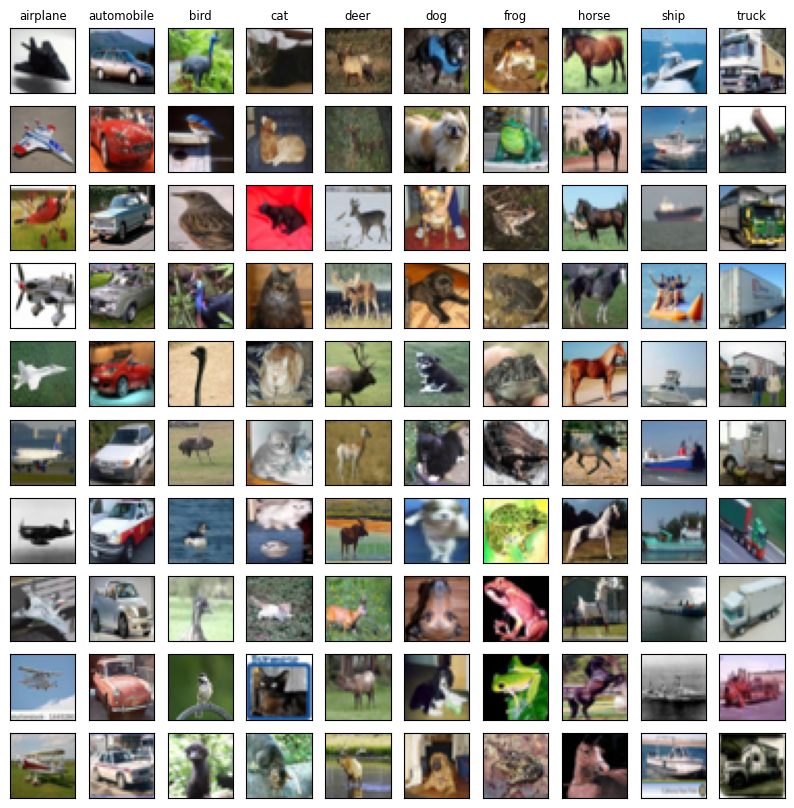

In [5]:
# Hint: To plot example images, you can use the plot examples function
plot_examples(x_train, y_train)

In [6]:
# convert labels ("0"-"9") to one-hot encodings, "0" = (1, 0, ... 0) and so on
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)[:8000]
y_valid_onehot = tf.keras.utils.to_categorical(y_test, 10)[8000:]

# Hint: normalize the data
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0
# Hint: use 20% of the test data for validation
x_valid_norm = x_test_norm[8000:]
x_test_norm = x_test_norm[:8000]


We start with a fully connected network

In [7]:
# ----------------------------------------------------------
# Define model
# ----------------------------------------------------------
model = tf.keras.models.Sequential(
    [
        layers.Flatten(input_shape=(32, 32, 3)),  # (32,32,3) --> (3072)
        # this time the flatten operation is directly integrated into the network
        # structure so that we can use the same input data later for a convolutional neural network.
        layers.Dense(100, activation="leaky_relu"),  # (3072) --> (100)
        layers.Dense(10, activation="softmax")  # (100) --> (10)
        # Hint: remember that the output layer should have 10 nodes with a softmax activation
    ],
    name="nn",
)

print(model.summary())

/opt/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
I0000 00:00:1781184419.165513    5010 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15102 MB memory:  -> device: 0, name: AMD Radeon RX 6950 XT, pci bus id: 0000:03:00.0


Model: "nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 308,310 (1.18 MB)

 Trainable params: 308,310 (1.18 MB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[tf.keras.metrics.CategoricalAccuracy()],
)

model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=32,
    epochs=20, # train at least for 20 epochs
    verbose=2,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name))],
)

Epoch 1/20


2026-06-11 13:27:01.364621: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f4e28006eb0 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
2026-06-11 13:27:01.364632: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): AMD Radeon RX 6950 XT, AMDGPU ISA version: gfx1030
2026-06-11 13:27:01.400712: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781184422.465320    5165 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-06-11 13:27:05.881619: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set

1563/1563 - 8s - 5ms/step - categorical_accuracy: 0.3151 - loss: 1.9429 - val_categorical_accuracy: 0.3695 - val_loss: 1.7922
Epoch 2/20
1563/1563 - 4s - 2ms/step - categorical_accuracy: 0.3733 - loss: 1.7770 - val_categorical_accuracy: 0.4035 - val_loss: 1.6996
Epoch 3/20
1563/1563 - 3s - 2ms/step - categorical_accuracy: 0.3980 - loss: 1.7076 - val_categorical_accuracy: 0.3940 - val_loss: 1.7168
Epoch 4/20
1563/1563 - 3s - 2ms/step - categorical_accuracy: 0.4164 - loss: 1.6506 - val_categorical_accuracy: 0.3585 - val_loss: 1.7650
Epoch 5/20
1563/1563 - 3s - 2ms/step - categorical_accuracy: 0.4309 - loss: 1.6126 - val_categorical_accuracy: 0.4145 - val_loss: 1.6214
Epoch 6/20
1563/1563 - 3s - 2ms/step - categorical_accuracy: 0.4397 - loss: 1.5824 - val_categorical_accuracy: 0.4230 - val_loss: 1.6400
Epoch 7/20
1563/1563 - 3s - 2ms/step - categorical_accuracy: 0.4487 - loss: 1.5582 - val_categorical_accuracy: 0.4260 - val_loss: 1.6023
Epoch 8/20
1563/1563 - 3s - 2ms/step - categorical_a

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


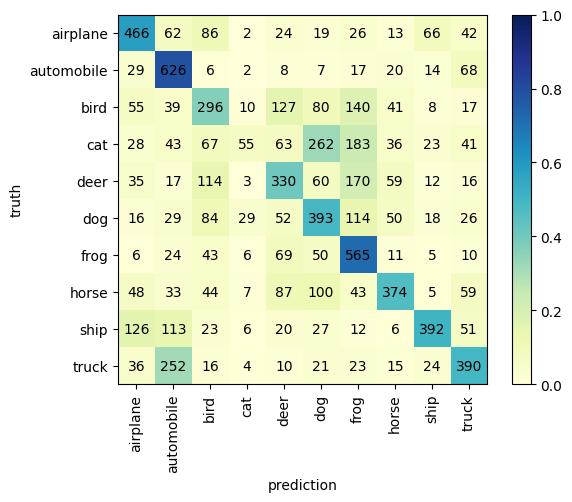

In [9]:
# ----------------------------------------------------------
# Plots
# ----------------------------------------------------------
# training curves
history = np.genfromtxt("history_{}.csv".format(model.name), delimiter=",", names=True)


# Hint: this is how you can plot the confusion matrix.
# calculate predictions for test set
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)

We can see that the network can predict frogs and ships somewhat consistently but struggles with most other categories. Cars and trucks have a lot of confusion with each other, which could probably happen to me as well. The network used does not seem very appropriate for the usecase.

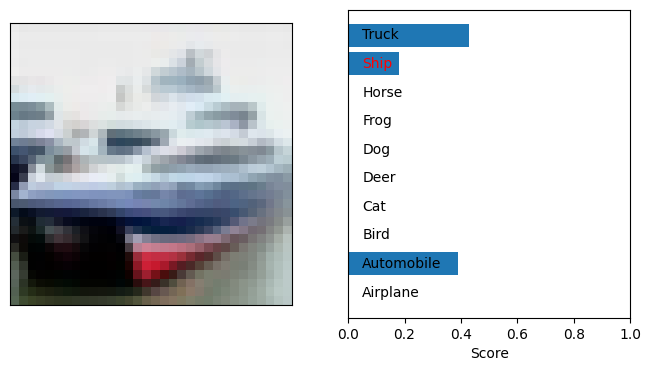

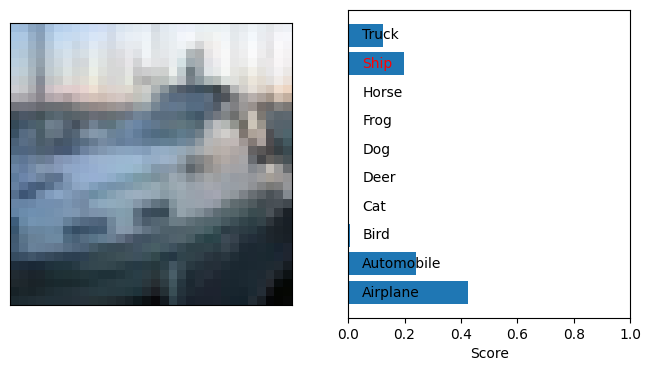

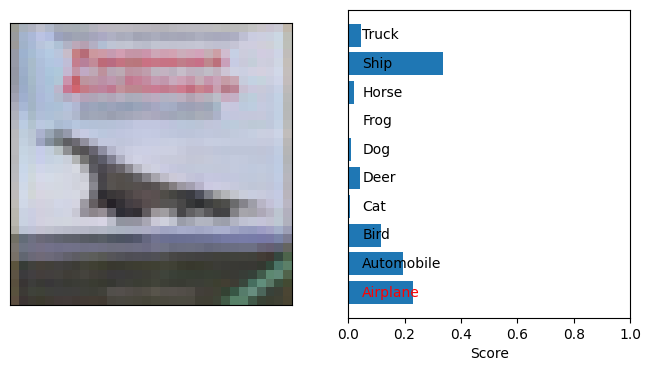

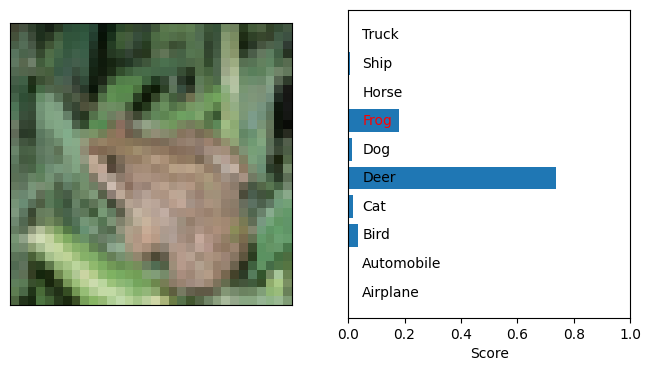

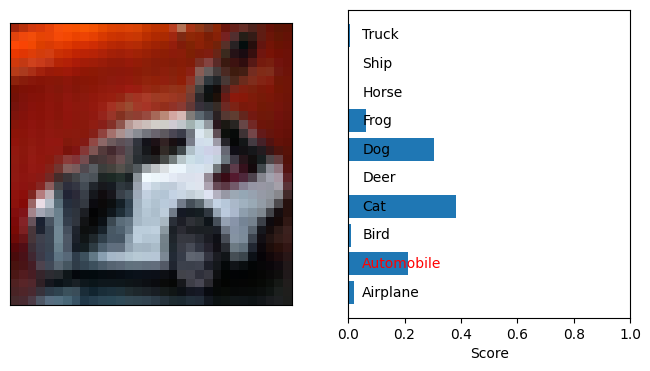

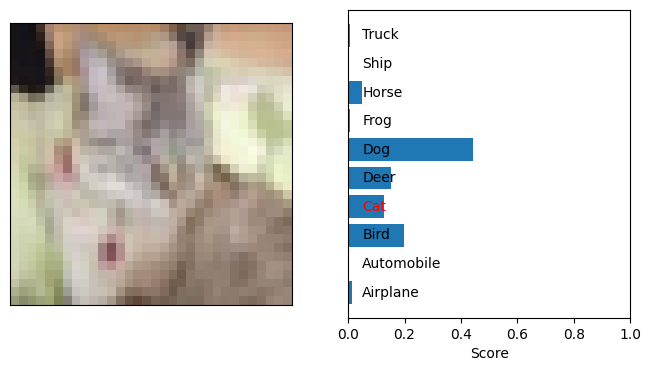

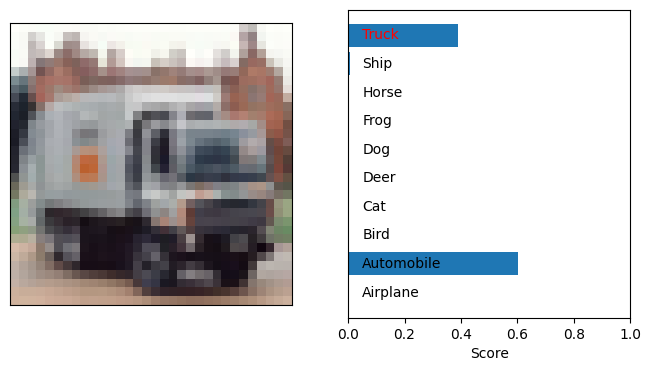

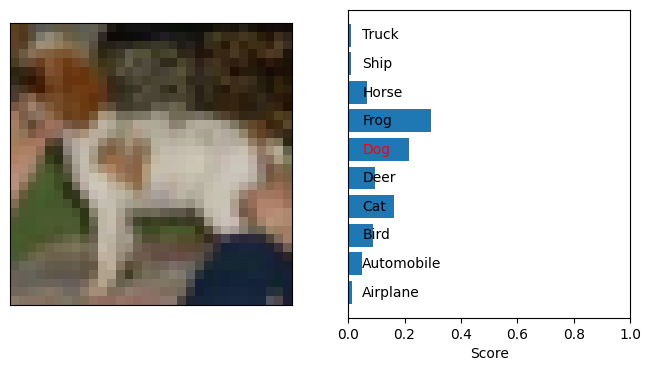

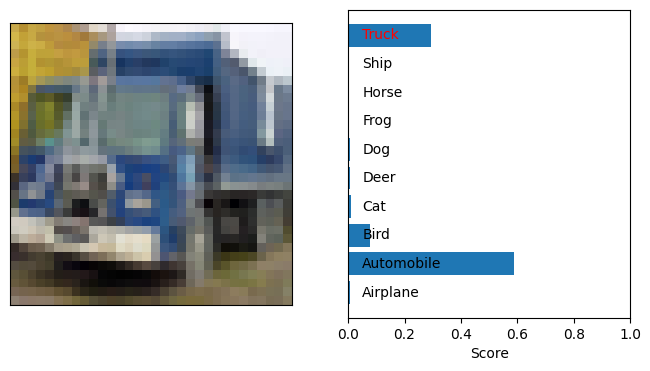

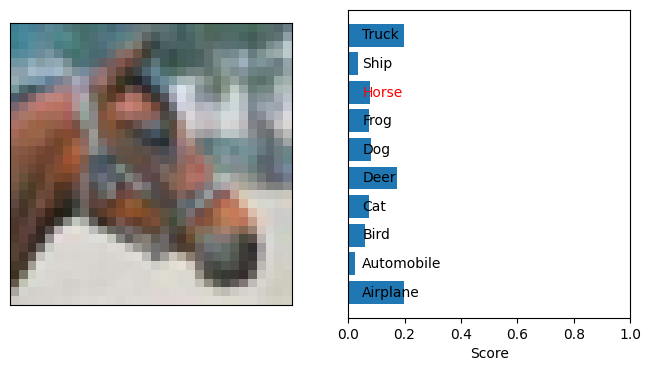

In [10]:
# Task: plot a few examples of correctly and incorrectly classified images.
# Hint: First find the indices of correctly and incorrectly classified images:
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images

# original (unnormalized) test images
x_test = x_test[:8000]

# Hint: Now you can use the `plot_prediction` function to plot the images:
# plot first 10 false classifications
for i in i0[0:10]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

Some of these misclassifications could've happened to me as well, e.g. the last plane which looks like a swallow.

**CNN**
In the second part of this exercise, classify the images with a CNN.


In [11]:
# Hint: this code snipped shows how to define convolution and maxpooling layers. For more information see
# https://keras.io/api/layers/convolution_layers/convolution2d/
# https://keras.io/api/layers/pooling_layers/max_pooling2d/
model = tf.keras.models.Sequential(
    [
        layers.Conv2D(16, kernel_size=(3, 3), padding="same", activation="relu", input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, kernel_size=(3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, kernel_size=(3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ],
    name="cnn",
)

print(model.summary())

/opt/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,570 (400.66 KB)

 Trainable params: 102,570 (400.66 KB)

 Non-trainable params: 0 (0.00 B)

None


In [12]:
# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=[tf.keras.metrics.CategoricalAccuracy()],
)

model.fit(
    x_train_norm,
    y_train_onehot,
    batch_size=32,
    epochs=40,
    validation_data=(x_valid_norm, y_valid_onehot),
    callbacks=[tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name))],
)

Epoch 1/40
1558/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - categorical_accuracy: 0.3220 - loss: 1.7994

2026-06-11 13:28:33.304005: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - categorical_accuracy: 0.3223 - loss: 1.7987

2026-06-11 13:28:38.138621: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - categorical_accuracy: 0.4133 - loss: 1.5826 - val_categorical_accuracy: 0.5375 - val_loss: 1.2676
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - categorical_accuracy: 0.5643 - loss: 1.2114 - val_categorical_accuracy: 0.6240 - val_loss: 1.0889
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - categorical_accuracy: 0.6291 - loss: 1.0503 - val_categorical_accuracy: 0.6370 - val_loss: 1.0251
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - categorical_accuracy: 0.6638 - loss: 0.9516 - val_categorical_accuracy: 0.6795 - val_loss: 0.9254
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - categorical_accuracy: 0.6894 - loss: 0.8824 - val_categorical_accuracy: 0.6915 - val_loss: 0.8534
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - categorical_accuracy: 0.7077 - loss: 0.8297 - val_categorical_accuracy: 0.7060 - val_loss: 0.8125
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - categorical_accuracy: 0.7220

2026-06-11 13:35:19.504392: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step


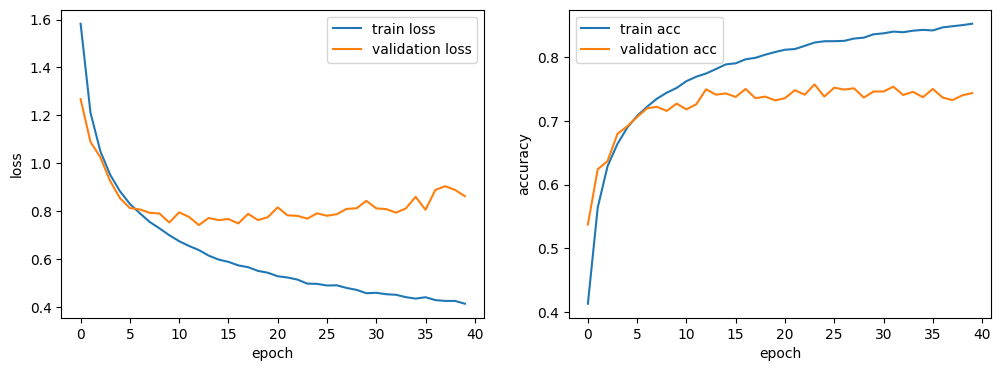

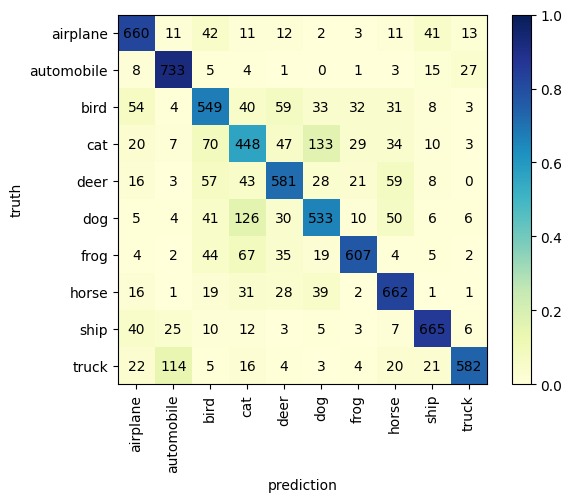

In [13]:
# ----------------------------------------------------------
# Plots
# ----------------------------------------------------------
# training curves
history = np.genfromtxt("history_{}.csv".format(model.name), delimiter=",", names=True)
fig, ax = plt.subplots(1,2, figsize=(12, 4))

ax[0].plot(history["epoch"], history["loss"], label="train loss")
ax[0].plot(history["epoch"], history["val_loss"], label="validation loss")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].legend()

ax[1].plot(history["epoch"], history["categorical_accuracy"], label="train acc")
ax[1].plot(history["epoch"], history["val_categorical_accuracy"], label="validation acc")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].legend()


# Hint: this is how you can plot the confusion matrix.
# calculate predictions for test set
y_predict = model.predict(x_test_norm, batch_size=128)

# convert back to class labels (0-9)
y_predict_cl = np.argmax(y_predict, axis=1)
y_test_cl = np.argmax(y_test_onehot, axis=1)

# plot confusion matrix
plot_confusion(y_test_cl, y_predict_cl)

As we can see here, the performance of a CNN is much better for image classification. While all categories get recognized less than 70 percent, at least there is a clear trend visible towards each  class being most likely being predicted correctly. The outliers make more sense here as well. Again confusing cars with trucks makes sense, the same for cats and dogs.

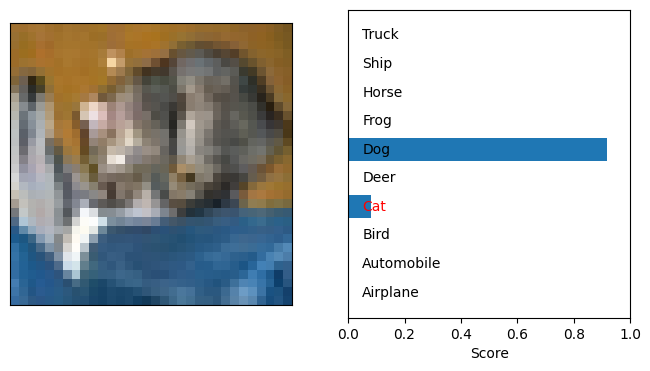

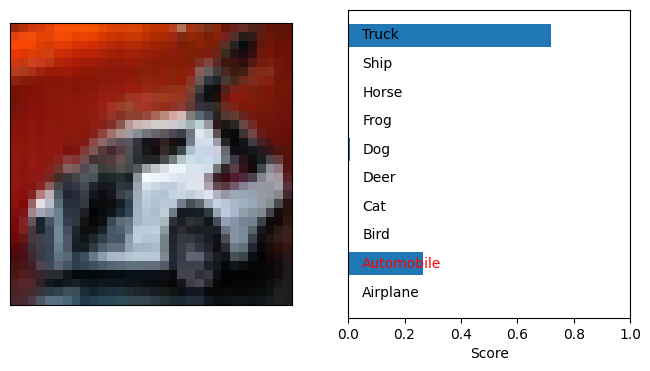

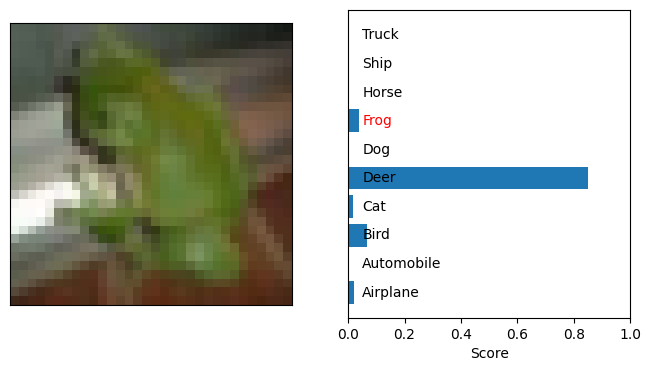

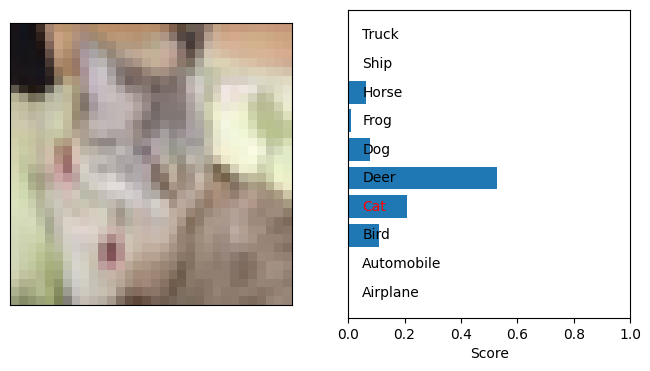

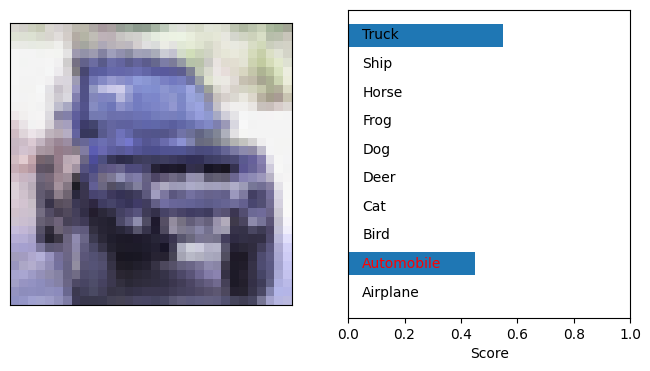

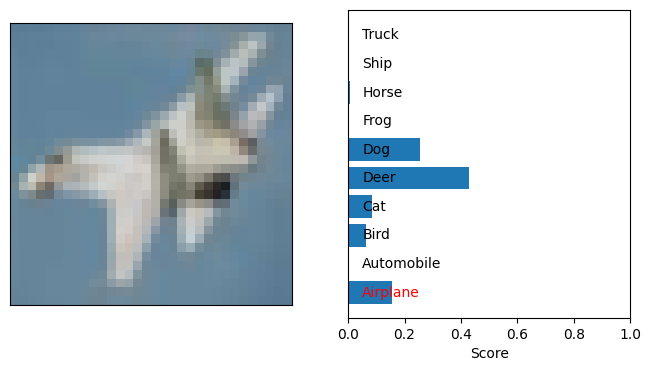

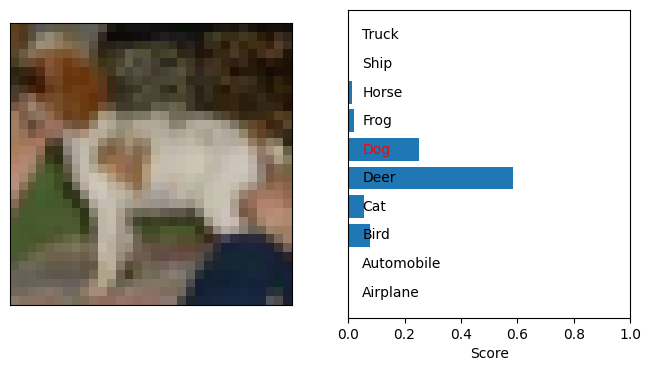

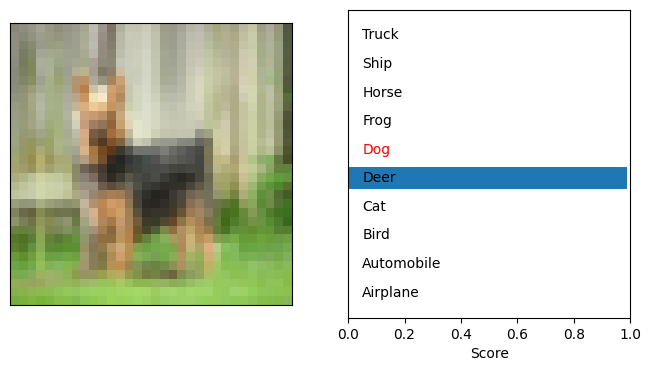

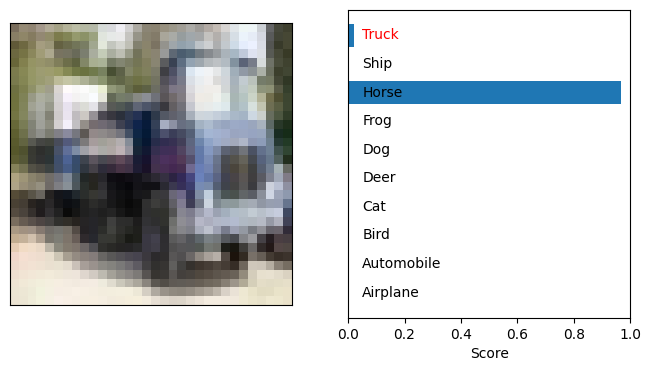

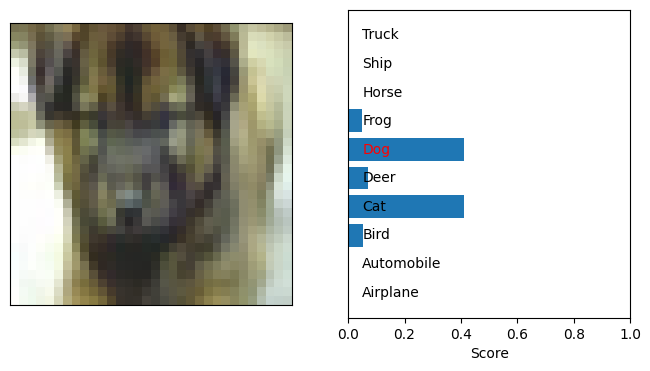

In [14]:
# Task: plot a few examples of correctly and incorrectly classified images.
# Hint: First find the indices of correctly and incorrectly classified images:
m = y_predict_cl == y_test_cl
i0 = np.arange(8000)[~m]  # misclassified images
i1 = np.arange(8000)[m]  # correctly classified images

# original (unnormalized) test images
x_test = x_test[:8000]

# Hint: Now you can use the `plot_prediction` function to plot the images:
# plot first 10 false classifications
for i in i0[0:10]:
    plot_prediction(x_test[i], y_test_onehot[i], y_predict[i])

Even more as with the first network, many misclassifications could also happen to a human.